In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

import numpy as np
import openml

from data_prep import ColumnSelector
from missing import *
from unlabeled_lr import UnlabeledLogReg

from numpy.typing import ArrayLike

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    accuracy_score
)

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier


pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("selector", ColumnSelector(threshold=0.7)),
    ]
)

def run_experiment(
        X: ArrayLike | pd.DataFrame, 
        y: ArrayLike | pd.Series | pd.DataFrame, 
        mnar_w: float, 
        mar1w: float, 
        mar1b: float, 
        seeds: list[int], 
        approaches: list[str],
        k_best: list[int],
        verbose: bool = False
        ) -> pd.DataFrame:
    """
    Executes an experiment to evaluate different semi-supervised learning 
    approaches for handling missing labels under various missing data mechanisms.

    The function splits the dataset into train, validation, and test sets, applies 
    a preprocessing pipeline, and artificially removes labels based on MCAR, MAR1, 
    MAR2, and MNAR schemes. It then trains an UnlabeledLogReg model using the 
    specified approaches and compares their performance against an Oracle baseline.

    Args:
        X (ArrayLike or pd.DataFrame): The input features dataset.
        y (ArrayLike or pd.Series): The binary target variable.
        mnar_w (float): The weight applied to the true label (Y) in the MNAR scheme.
        mar1w (float): The weight applied to the randomly selected feature in the MAR1 scheme.
        mar1b (float): The bias (intercept) term used in the MAR1 scheme.
        seeds (list[int]): A list of random seeds for reproducible experimental runs.
        approaches (list[str]): A list of string identifiers for the imputation 
            methods to evaluate (e.g., ['naive', 'pseudo_labels']).

    Returns:
        pd.DataFrame: A DataFrame containing the evaluation metrics (Accuracy, 
            Balanced_Acc, F1, ROC_AUC) and the percentage of missing data 
            for each seed, scheme, and approach.
    """
    
    y = np.asarray(y).ravel()
    results = []

    for seed in seeds:
        
        np.random.seed(seed)
        print(f"\n{'='*40}\nExperiment for SEED: {seed}\n{'='*40}")
        
        #Train (60%), Val (20%), Test (20%)

        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y, test_size=0.2, random_state=seed, stratify=y
        )
        
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp, test_size=0.25, random_state=seed, stratify=y_temp
        )
        
        X_train = pipeline.fit_transform(X_train, y_train)
        X_val = pipeline.transform(X_val)
        X_test = pipeline.transform(X_test)
        
        X_train_df = pd.DataFrame(X_train)
        
        y_train_df = pd.DataFrame(y_train, columns=['Y_true_unobserved'])
        y_train_without_missing = y_train_df['Y_true_unobserved'].copy()
        
        y_train_df["Y_observed"] = y_train_df["Y_true_unobserved"].copy().astype(int)
        y_train_df["S"] = 0
        y_train_df["Missing_Y"] = "no"
        
        
        random_col_name = np.random.choice(X_train_df.columns)
        schemes_config = [
        {'name': 'MCAR_0.2', 'type': 'MCAR', 'params': {'p': 0.2}},
        {'name': 'MCAR_0.5', 'type': 'MCAR', 'params': {'p': 0.5}},
        {'name': 'MCAR_0.8', 'type': 'MCAR', 'params': {'p': 0.8}},
        {'name': 'MAR1',     'type': 'MAR1', 'params': {'w': mar1w, 'b': mar1b, 'feature_column': random_col_name}},
        {'name': 'MAR2',     'type': 'MAR2', 'params': {}}, 
        {'name': 'MNAR',     'type': 'MNAR', 'params': {'w_y': mnar_w}}
        ]

        # oracle
        if verbose:
            print("  -> Training approach ORACLE...")
        oracle_model = UnlabeledLogReg(y_imputation_method='naive') 
        oracle_model.fit(X_train, y_train_without_missing)
        
        oracle_model.validate(X_val, y_val, measure='balanced_accuracy')
        
        y_pred_oracle = oracle_model.predict(X_test)
        y_prob_oracle = oracle_model.predict_proba(X_test)
        
        results.append({
            'Seed': seed,
            'Scheme': 'None',
            'Approach': 'Oracle',
            'k_best': np.nan,
            'base_estimator': np.nan,
            'Missing_Percent': 0.0,
            'Accuracy': accuracy_score(y_test, y_pred_oracle),
            'Balanced_Acc': balanced_accuracy_score(y_test, y_pred_oracle),
            'F1': f1_score(y_test, y_pred_oracle),
            'ROC_AUC': roc_auc_score(y_test, y_prob_oracle)
        })

        # iteration over missing mechanisms
        for config in schemes_config:
            scheme_name = config['name']
            scheme_type = config['type']

            if verbose: print(f"  -> Testing scheme: {scheme_name}")
            
            if scheme_type == 'MCAR':
                y_missing_df = MCAR(y_train_df, **config['params'])
            elif scheme_type == 'MAR1':
                y_missing_df = MAR1(pd.DataFrame(X_train), y_train_df, **config['params'])
            elif scheme_type == 'MAR2':
                y_missing_df = MAR2(pd.DataFrame(X_train), y_train_df, **config['params'])
            elif scheme_type == 'MNAR':
                y_missing_df = MNAR(pd.DataFrame(X_train), y_train_df, **config['params'])
                
            y_train_obs = y_missing_df['Y_observed']
            
            #useful printing % of missing y info  
            missing_count = (y_train_obs == -1).sum()
            total_count = len(y_train_obs)
            missing_pct = round((missing_count / total_count) * 100, 2)

            if verbose: print(f"     [!] Deleted {missing_pct}% y info ({missing_count}/{total_count})")

            # iteration over approaches
            for approach in approaches:

                if verbose: print(f"     * Approach: {approach}")
                
                if approach == 'self_training':
                    classifiers = [
                        SVC(C=1.0, kernel='rbf', probability=True),
                        LogisticRegression(l1_ratio=0, C=10.0, max_iter=10_000),
                        RandomForestClassifier(),
                        XGBClassifier()
                    ]

                    for classifier in classifiers:
                        for k in k_best:

                            ulr_model = UnlabeledLogReg(y_imputation_method=approach, k_best=k, base_estimator=classifier)
                            ulr_model.fit(X_train, y_train_obs)
                    
                            # valdiation
                            ulr_model.validate(X_val, y_val, measure='balanced_accuracy')
                    
                            # calculating performance on outer test data
                            y_pred = ulr_model.predict(X_test)
                            y_prob = ulr_model.predict_proba(X_test)
                    
                            results.append({
                                'Seed': seed,
                                'Scheme': scheme_name,
                                'Approach': approach,
                                'k_best': k,
                                'base_estimator': classifier.__class__.__name__,
                                'Missing_Percent': missing_pct,
                                'Accuracy': accuracy_score(y_test, y_pred),
                                'Balanced_Acc': balanced_accuracy_score(y_test, y_pred),
                                'F1': f1_score(y_test, y_pred),
                                'ROC_AUC': roc_auc_score(y_test, y_prob)
                        })

                    continue

                ulr_model = UnlabeledLogReg(y_imputation_method=approach)
                ulr_model.fit(X_train, y_train_obs)
                
                # valdiation
                ulr_model.validate(X_val, y_val, measure='balanced_accuracy')
                
                # calculating performance on outer test data
                y_pred = ulr_model.predict(X_test)
                y_prob = ulr_model.predict_proba(X_test)
                
                results.append({
                    'Seed': seed,
                    'Scheme': scheme_name,
                    'Approach': approach,
                    'k_best': np.nan,
                    'base_estimator': np.nan,
                    'Missing_Percent': missing_pct,
                    'Accuracy': accuracy_score(y_test, y_pred),
                    'Balanced_Acc': balanced_accuracy_score(y_test, y_pred),
                    'F1': f1_score(y_test, y_pred),
                    'ROC_AUC': roc_auc_score(y_test, y_prob)
                })

    results_df = pd.DataFrame(results)
    print("End of experiment")
    
    return results_df

In [ ]:
def plot_experiment_results(df: pd.DataFrame, metric: str, best_estimator: str, best_k: int) -> None:
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))
    
    oracle_data = df[df['Approach'] == 'Oracle']
    oracle_mean = oracle_data[metric].mean()
    
    plot_data = df[df['Approach'] != 'Oracle']
    
    ax = sns.boxplot(
        data=plot_data, 
        x='Scheme', 
        y=metric, 
        hue='Approach',
        palette='Set2',
        linewidth=1.5,
        fliersize=5
    )
    
    plt.axhline(
        y=oracle_mean, 
        color='red', 
        linestyle='--', 
        linewidth=2,
        label=f'Oracle Mean ({oracle_mean:.3f})'
    )
    
    plt.title(f'Comparison of approaches - {metric}', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Missing Data Mechanism', fontsize=13)
    plt.ylabel(f'{metric} (test data)', fontsize=13)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    
    handles, _ = ax.get_legend_handles_labels()
    plt.legend(
        handles=handles, 
        title='Approach', 
        title_fontsize=12,
        bbox_to_anchor=(1.02, 1), 
        loc='upper left',
        borderaxespad=0.
    )
    
    plt.tight_layout()
    

In [ ]:
def generate_summary_table(df: pd.DataFrame) -> pd.DataFrame:
    expected_metrics = ['Missing_Percent', 'Accuracy', 'Balanced_Acc', 'F1', 'ROC_AUC']
    metrics = [m for m in expected_metrics if m in df.columns]
    
    grouped = df.groupby(['Scheme', 'Approach'])[metrics]
    
    mean_df = grouped.mean()
    std_df = grouped.std().fillna(0) 
    
    summary_df = pd.DataFrame(index=mean_df.index)
    
    for col in metrics:
        if col == 'Missing_Percent':
            summary_df[col] = (
                mean_df[col].map('{:.1f}'.format) + "% ± " + 
                std_df[col].map('{:.1f}'.format) + "%"
            )
        else:
            summary_df[col] = (
                mean_df[col].map('{:.3f}'.format) + " ± " + 
                std_df[col].map('{:.3f}'.format)
            )
            
    return summary_df.reset_index()

In [7]:
# for experiment
seeds = list(range(40))
approaches = ['naive', 'self_training', 'label_propagation']

# for visualizations
metrics_to_plot = ['Accuracy', 'Balanced_Acc', 'F1', 'ROC_AUC']

k_best = [1]

In [8]:
import pandas as pd

def load_arff(filepath):
    columns = []
    data = []
    in_data = False
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('%') or not line:
                continue
            if line.upper().startswith('@ATTRIBUTE'):
                parts = line.split(None, 2)  # max 3 części
                col_name = parts[1]
                columns.append(col_name)
            elif line.upper().startswith('@DATA'):
                in_data = True
            elif in_data:
                data.append(line.split(','))
    
    return pd.DataFrame(data, columns=columns)

lsvt = load_arff('../data/raw/lsvt.arff')

X = lsvt.iloc[:, :-1].to_numpy()
y = lsvt.iloc[:, [-1]].to_numpy()
y
y = np.where(y == '2', 1, 0).astype(int)

results_lsvt = run_experiment(X, y, mnar_w = 2, mar1w=2, mar1b=0, seeds=seeds, approaches=approaches, k_best=k_best)


Experiment for SEED: 0

Experiment for SEED: 1

Experiment for SEED: 2

Experiment for SEED: 3

Experiment for SEED: 4

Experiment for SEED: 5

Experiment for SEED: 6

Experiment for SEED: 7

Experiment for SEED: 8

Experiment for SEED: 9

Experiment for SEED: 10

Experiment for SEED: 11

Experiment for SEED: 12

Experiment for SEED: 13

Experiment for SEED: 14

Experiment for SEED: 15

Experiment for SEED: 16

Experiment for SEED: 17

Experiment for SEED: 18

Experiment for SEED: 19

Experiment for SEED: 20

Experiment for SEED: 21

Experiment for SEED: 22

Experiment for SEED: 23

Experiment for SEED: 24

Experiment for SEED: 25

Experiment for SEED: 26

Experiment for SEED: 27

Experiment for SEED: 28

Experiment for SEED: 29

Experiment for SEED: 30

Experiment for SEED: 31

Experiment for SEED: 32

Experiment for SEED: 33

Experiment for SEED: 34

Experiment for SEED: 35

Experiment for SEED: 36

Experiment for SEED: 37

Experiment for SEED: 38

Experiment for SEED: 39
End of exp

In [9]:
darwin = pd.read_csv('../data/raw/DARWIN.csv')

X = darwin.iloc[:, 1:-1].to_numpy()
y = darwin.iloc[:, -1].to_numpy()
y = np.where(y == 'P', 1, 0)

results_darwin = run_experiment(X, y, mnar_w=2, mar1w=2, mar1b=0, seeds=seeds, approaches=approaches, k_best=k_best)


Experiment for SEED: 0

Experiment for SEED: 1

Experiment for SEED: 2

Experiment for SEED: 3

Experiment for SEED: 4

Experiment for SEED: 5

Experiment for SEED: 6

Experiment for SEED: 7

Experiment for SEED: 8

Experiment for SEED: 9

Experiment for SEED: 10

Experiment for SEED: 11

Experiment for SEED: 12

Experiment for SEED: 13

Experiment for SEED: 14

Experiment for SEED: 15

Experiment for SEED: 16

Experiment for SEED: 17

Experiment for SEED: 18

Experiment for SEED: 19

Experiment for SEED: 20

Experiment for SEED: 21

Experiment for SEED: 22

Experiment for SEED: 23

Experiment for SEED: 24

Experiment for SEED: 25

Experiment for SEED: 26

Experiment for SEED: 27

Experiment for SEED: 28

Experiment for SEED: 29

Experiment for SEED: 30

Experiment for SEED: 31

Experiment for SEED: 32

Experiment for SEED: 33

Experiment for SEED: 34

Experiment for SEED: 35

Experiment for SEED: 36

Experiment for SEED: 37

Experiment for SEED: 38

Experiment for SEED: 39
End of exp

In [22]:
def set_best_st_approach(df):
    df = results_darwin

    df_st = df[df['Approach'] == 'self_training'].copy()
    df_st['Config'] = df_st['base_estimator'] + "_k=" + df_st['k_best'].astype(str)

    # best in terms of median for F1
    global_medians = df_st.groupby('Config')['F1'].median()  
    best_config = global_medians.idxmax()
    print(f"`Best` Self-Training configuration: {best_config}")

    best_estimator = best_config.split('_k=')[0]
    # best_k = int(best_config.split('_k=')[1])
    best_k = 1

    mask_other = df['Approach'] != 'self_training'
    mask_best_st = (
        (df['Approach'] == 'self_training') & 
        (df['base_estimator'] == best_estimator) & 
        (df['k_best'] == best_k)
    )

    df_plot = df[mask_other | mask_best_st].copy()

    df_plot.loc[df_plot['Approach'] == 'self_training', 'Approach'] = f'Self-Training ({best_config})'
    return df_plot

# for metric in metrics_to_plot:
#     plot_experiment_results(df_plot, metric=metric, best_estimator=None,  best_k=best_k)

In [10]:
parkinson = pd.read_csv('../data/raw/parkinson.csv')
X = parkinson.iloc[:, 1:-1].to_numpy()
y = parkinson.iloc[:, -1].to_numpy()

results_parkinson = run_experiment(X, y, mnar_w=2, mar1w=2, mar1b=0, seeds=seeds, approaches=approaches, k_best=k_best)


Experiment for SEED: 0

Experiment for SEED: 1

Experiment for SEED: 2

Experiment for SEED: 3

Experiment for SEED: 4

Experiment for SEED: 5

Experiment for SEED: 6

Experiment for SEED: 7

Experiment for SEED: 8

Experiment for SEED: 9

Experiment for SEED: 10

Experiment for SEED: 11

Experiment for SEED: 12

Experiment for SEED: 13

Experiment for SEED: 14

Experiment for SEED: 15

Experiment for SEED: 16

Experiment for SEED: 17

Experiment for SEED: 18

Experiment for SEED: 19

Experiment for SEED: 20

Experiment for SEED: 21

Experiment for SEED: 22

Experiment for SEED: 23

Experiment for SEED: 24

Experiment for SEED: 25

Experiment for SEED: 26

Experiment for SEED: 27

Experiment for SEED: 28

Experiment for SEED: 29

Experiment for SEED: 30

Experiment for SEED: 31

Experiment for SEED: 32

Experiment for SEED: 33

Experiment for SEED: 34

Experiment for SEED: 35

Experiment for SEED: 36

Experiment for SEED: 37

Experiment for SEED: 38

Experiment for SEED: 39
End of exp

### prostate

In [35]:
prostate = pd.read_csv('../data/raw/prostmat.csv', header=None).T

prostate_X = prostate.iloc[:, 1:].to_numpy()
prostate_y = prostate.iloc[:, 0].to_numpy()
prostate_y = np.where(prostate_y == 'cancer', 1, 0).astype(int)

seeds = list(range(40))
results_prostate = run_experiment(prostate_X, prostate_y, mnar_w=2, mar1w=2, mar1b=0, seeds=seeds, approaches=approaches, k_best=k_best)


Experiment for SEED: 0

Experiment for SEED: 1

Experiment for SEED: 2

Experiment for SEED: 3

Experiment for SEED: 4

Experiment for SEED: 5

Experiment for SEED: 6

Experiment for SEED: 7

Experiment for SEED: 8

Experiment for SEED: 9

Experiment for SEED: 10

Experiment for SEED: 11

Experiment for SEED: 12

Experiment for SEED: 13

Experiment for SEED: 14

Experiment for SEED: 15

Experiment for SEED: 16

Experiment for SEED: 17

Experiment for SEED: 18

Experiment for SEED: 19

Experiment for SEED: 20

Experiment for SEED: 21

Experiment for SEED: 22

Experiment for SEED: 23

Experiment for SEED: 24

Experiment for SEED: 25

Experiment for SEED: 26

Experiment for SEED: 27

Experiment for SEED: 28

Experiment for SEED: 29

Experiment for SEED: 30

Experiment for SEED: 31

Experiment for SEED: 32

Experiment for SEED: 33

Experiment for SEED: 34

Experiment for SEED: 35

Experiment for SEED: 36

Experiment for SEED: 37

Experiment for SEED: 38

Experiment for SEED: 39
End of exp

#### Save results

In [ ]:
results_lsvt.to_csv('../results/results_lsvt.csv', index=False)
results_darwin.to_csv('../results/results_darwin.csv', index=False)
results_parkinson.to_csv('../results/results_parkinson.csv', index=False)
results_prostate.to_csv('../results/results_prostate.csv', index=False)

`Best` Self-Training configuration: RandomForestClassifier_k=1.0


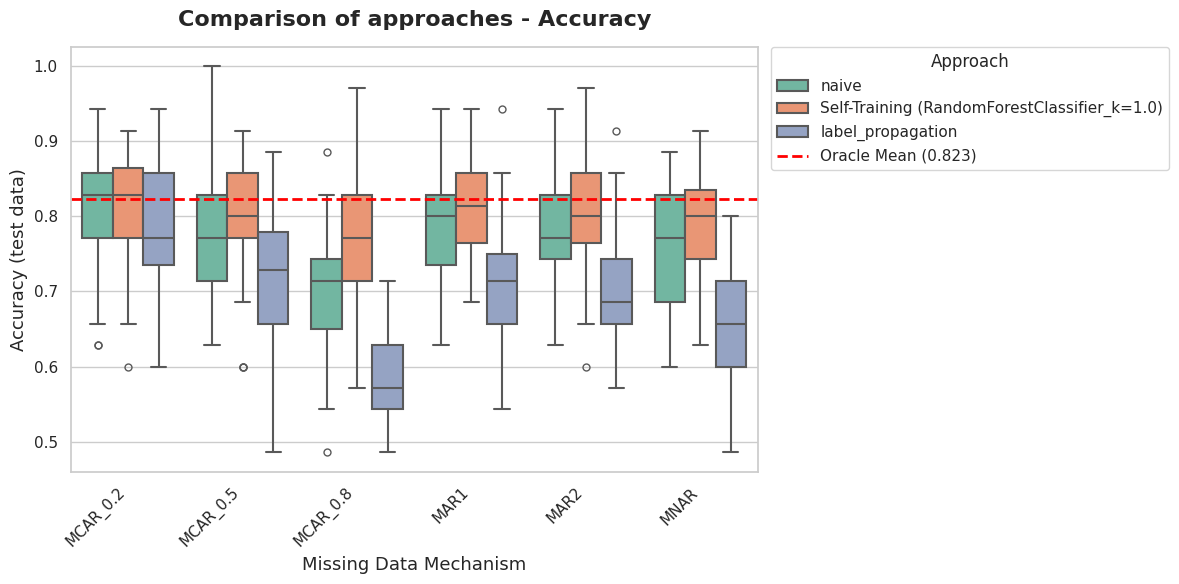

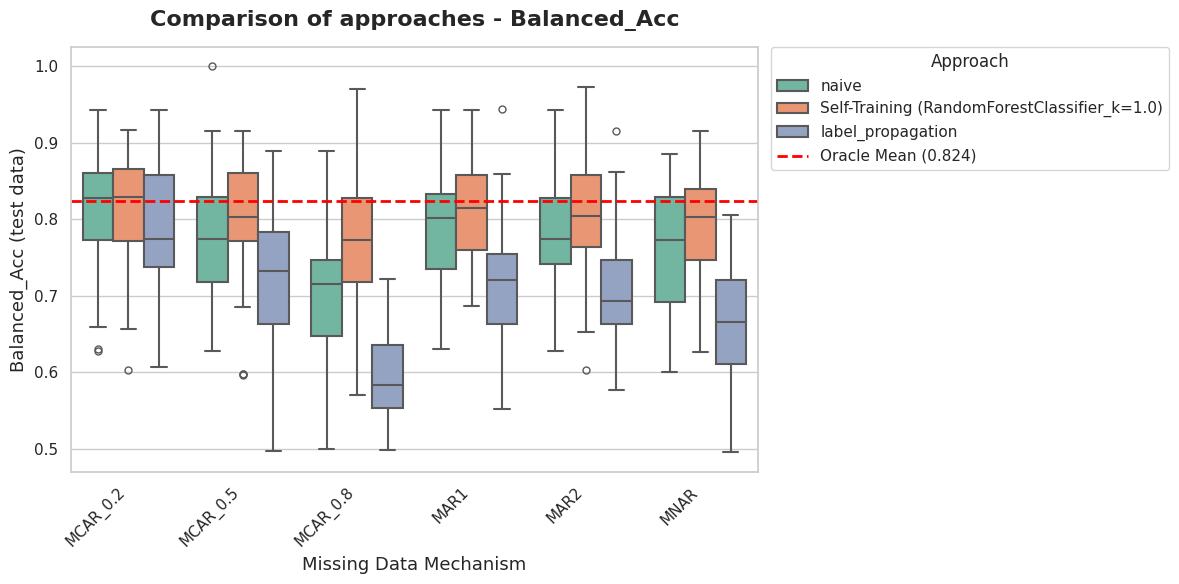

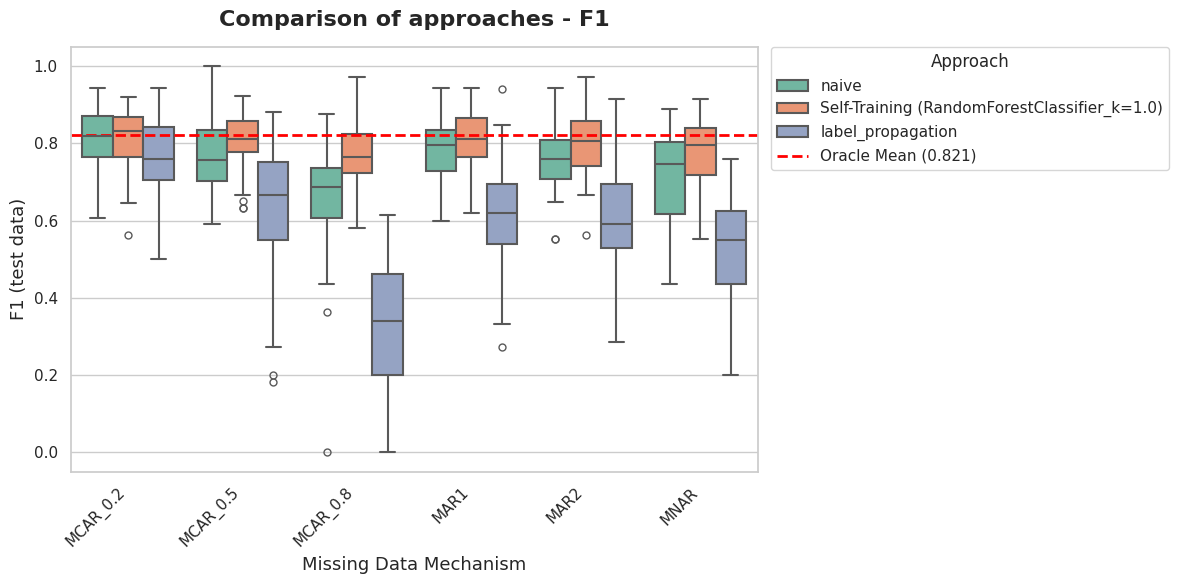

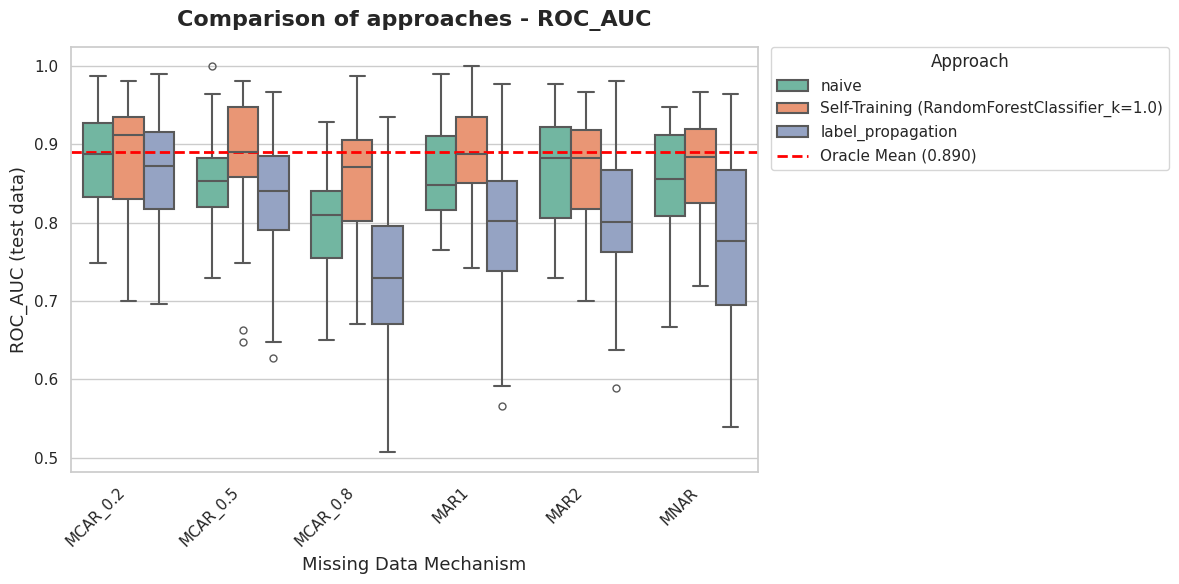

In [37]:
df_plot = set_best_st_approach(results_prostate)
for measure in metrics_to_plot:
    plot_experiment_results(df_plot, measure, '', 1)
# plt.ylim(0.75, 0.95)
plt.show()